# Improving Low Cost AIr Quality Sensor Accuracy with Simple Machine Learning Model

### Reasearch Question: Can machine learning improve the accuracy of low cost sensor readings?

## loading and exploring data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("data/SingleSensor_CalibData.csv") 

In [3]:
df.head()

,Time_Beirut,PM2.5 ConHR(ug/m3),PM10 ConHR(ug/m3),meanAB_2_5,meanAB_10
0,2020-07-01 03:00:00,15,45,28.224000,29.909167
1,2020-07-01 04:00:00,18,39,24.902333,26.259833
2,2020-07-01 05:00:00,17,36,25.944500,27.560000
3,2020-07-01 06:00:00,19,42,22.618333,24.114000
4,2020-07-01 07:00:00,10,28,21.959500,23.402833


In [4]:
df.shape

(2163, 5)

In [5]:
df.isnull().sum()

Time_Beirut           0
PM2.5 ConHR(ug/m3)    0
PM10 ConHR(ug/m3)     0
meanAB_2_5            0
meanAB_10             0
dtype: int64

In [6]:
df[["PM2.5 ConHR(ug/m3)", "meanAB_2_5"]].head()

,PM2.5 ConHR(ug/m3),meanAB_2_5
0,15,28.224000
1,18,24.902333
2,17,25.944500
3,19,22.618333
4,10,21.959500


## measuring intial sensor error

In [7]:
df["error"] = df["meanAB_2_5"] - df["PM2.5 ConHR(ug/m3)"]

In [8]:
df[["PM2.5 ConHR(ug/m3)", "meanAB_2_5", "error"]].head()

,PM2.5 ConHR(ug/m3),meanAB_2_5,error
0,15,28.224000,13.224000
1,18,24.902333,6.902333
2,17,25.944500,8.944500
3,19,22.618333,3.618333
4,10,21.959500,11.959500


In [9]:
df["absolute_error"] = df["error"].abs()

In [10]:
df["absolute_error"].mean()

np.float64(11.791792253888714)

## comparing low cost and the reference sensor readings

Text(0.5, 1.0, 'Low Cost Sensor vs Reference PM2.5')

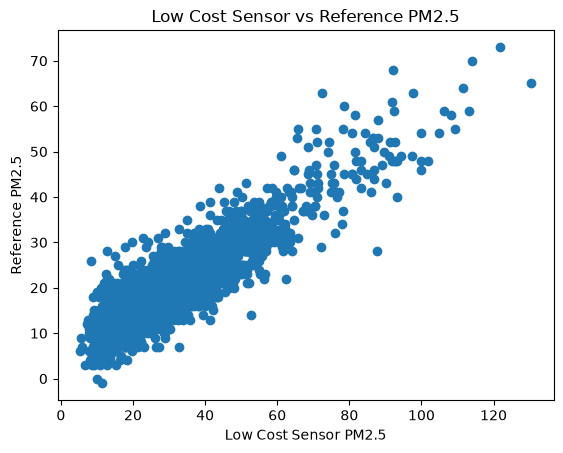

In [11]:
plt.scatter(df["meanAB_2_5"], df["PM2.5 ConHR(ug/m3)"])
plt.xlabel("Low Cost Sensor PM2.5")
plt.ylabel("Reference PM2.5")
plt.title("Low Cost Sensor vs Reference PM2.5")

## preparing data for ml 

In [12]:
X = df[["meanAB_2_5"]]
y = df["PM2.5 ConHR(ug/m3)"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
len(X_train), len(X_test)

(1730, 433)

## training the linear regression model

In [15]:
model = LinearRegression()

In [16]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.49]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['meanAB_2_5']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.309
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [17]:
predictions = model.predict(X_test)

## evaluating how well the model works

In [18]:
model_mae = mean_absolute_error(y_test, predictions)

In [19]:
model_mae

3.558435170770394

In [20]:
raw_test_mae = mean_absolute_error(y_test, X_test["meanAB_2_5"])

In [21]:
raw_test_mae

11.580289838337183

In [22]:
from sklearn.metrics import mean_squared_error

In [23]:
rmse = mean_squared_error(y_test, predictions) ** 0.5

In [24]:
rmse

4.445230533262638

In [25]:
from sklearn.metrics import r2_score

In [28]:
r2 = r2_score(y_test, predictions)

In [29]:
r2

0.7982802072357227

In [30]:
improvement_percent = (raw_test_mae - model_mae) / raw_test_mae * 100

In [31]:
improvement_percent

69.27162255481724

## comparing original and corrected sensor readings

Text(0.5, 1.0, 'Raw vs Calibrated PM2.5 Measurements')

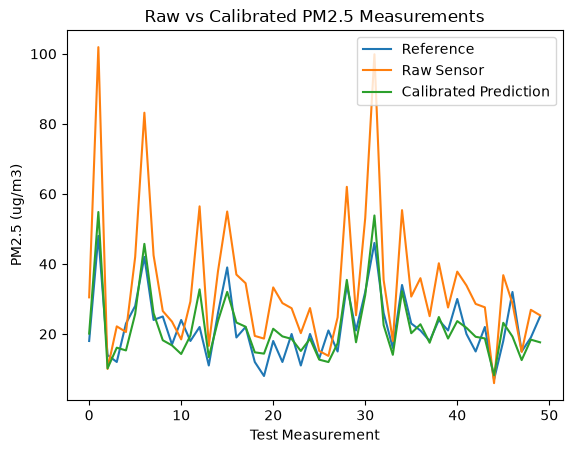

In [37]:
plt.plot(y_test.values[:50], label="Reference")
plt.plot(X_test["meanAB_2_5"].values[:50], label="Raw Sensor")
plt.plot(predictions[:50], label="Calibrated Prediction")
plt.legend()
plt.xlabel("Test Measurement")
plt.ylabel("PM2.5 (ug/m3)")
plt.title("Raw vs Calibrated PM2.5 Measurements")

## results and limitations

In [38]:
model.coef_

array([0.48591999])

In [39]:
model.intercept_

np.float64(5.30945902951769)

### Results: 
The simple ml model improved the low cost sensor readings on the test data. The original sensor had MAE of 11.85 uq/m^3, while the corrected readings had MAE of 3.56 uq/m^3. This means that the model reduced the MAE by about  69%. The model also had an RMSE of 4.45 uq/m^3 and R^2 of about 0.80.

### Limitations:
 The model was trained on data from specific sensors. Other sensors may have different accuracy and error patterns. Different environmental conditions might also affect sensor readings. In addition, the model only uses the original PM2.5 reading and does not consider other information, such as humidity or temperature. Therefore, the results from this project are specific to the sensors and conditions represented in this datset and might not apply to other sensors or environments.